In [1]:
# моделирование линейной системы
# взаимодействующих друг с другом
# магнитных спинов

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение метода norm из библиотеки stat
from scipy.stats import norm


In [ ]:
# Ячейка № 2

# задание функции, возвращающей мгновенные значения:
# полной энергии системы;
# энергии демона;
# суммарного магнитного момента
# моделируемой системы
def Ising_KA(N_x, N_y, J, h, N_Trial, T):
    # N_x, N_y  - узлов координатной сетки по соответствующим осям
    # J - константа обменного взаимодействия
    # h - внешнее магнитное поле
    # N_Trial - число независимых испытаний в методе Монте-Карло

    s = np.zeros([N_y, N_x, N_Trial + 1])
    # число спинов моделируемой системы
    N_Spin = N_x * N_y

    # инициализация начальной конфигурации спинов
    S = np.ones([N_y, N_x])

    s[:, :, 0] = S[:, :]
    # вычисление начального значения энергии системы
    E_System_Test = int(-(J + h) * N_Spin)

    # инициализация массивов, используемых
    # для хранения мгновенных значений:
    # полной энергии системы (E_System);
    # суммарного магнитного момента
    # моделируемой системы (Summry_Spin_Moment)
    E_System = np.zeros(N_Trial + 1, dtype="int")
    Summary_Spin_Moment = np.zeros(N_Trial + 1, dtype="int")
    Accept = np.zeros(N_Trial + 1)

    # сохранение начальных значений
    # полной энергии системы;
    # энергии демона;
    # суммарного магнитного момента
    # моделируемой системы (Summry_Spin_Moment)
    E_System[0] = E_System_Test
    Summary_Spin_Moment[0] = N_Spin

    # реализация метода микроканонического ансамбля
    k = 0

    for i in range(1, N_Trial + 1):
        # подсчитываем число принятых
        # пробных переворотов спинов
        # на каждом шаге метода Монте-Карло
        N_Accept = 0
        for j in range(N_Spin):
            # случайный выбор координат переворачиваемого спина
            I_x = int(random.uniform(0, N_x))
            I_y = int(random.uniform(0, N_y))

            # выбираем номера соседних
            # с переворачиваемым спином
            #  с учетом периодических граничных условий
            if I_x == 0:
                Left = N_x - 1
                Right = 1
            if I_x == N_x - 1:
                Left = I_x - 1
                Right = 0
            if I_y == 0:
                Down = N_y - 1
                Up = 1
            if I_y == N_y - 1:
                Up = 0
                Down = I_y - 1
            # задаем номера соседних спинов,
            # если переворачиваемый спин
            # не находится на границе двумерной области
            if (I_x != 0) & (I_x != N_x - 1):
                Left = I_x - 1
                Right = I_x + 1
            if (I_y != 0) & (I_y != N_y - 1):
                Down = I_y - 1
                Up = I_y + 1

            # вычисление энергии спина
            # после его пробного переворота
            D_E = (
                2
                * S[I_y, I_x]
                * (-h + J * (S[I_y, Left] + S[I_y, Right] + S[Down, I_x] + S[Up, I_x]))
            )

            if D_E <= 0 or (D_E > 0 and random.uniform(0, 1) <= np.exp(-D_E / T)):
                # изменение ориентации спина принимается

                S[I_y, I_x] = -S[I_y, I_x]
                N_Accept = N_Accept + 1
                E_System_Test = E_System_Test + D_E
        k = k + 1
        # сохранение на каждом шаге
        # метода метода Монте-Карло значений:
        # энергии системы, энергии демона,
        # суммарного магнитного момента системы спинов,
        # числа принятых пробных переворотов спина,
        # нормированного на число спинов,
        # текущей конфигурации спинов
        E_System[k] = E_System_Test
        Summary_Spin_Moment[k] = np.sum(S)
        Accept[k] = N_Accept / N_Spin
        s[:, :, i] = S[:, :]

    return E_System, Summary_Spin_Moment, Accept, s


In [ ]:
# Ячейка № 3

# вычисление и визуализация
# последовательностей, составленных из
# мгновенных значений энергий системы спинов,
# суммарного магнитного момента системы спинов,
# мгновенного числа принятых решений

# инициализация генератора случайных чисел
random.seed()

# задание числа спинов
N_x = 20

N_y = 20

# задание значения спина
J = 1

# задание напряженности магнитного поля
h = 0

# задание числа испытаний метода Монте-Карло
N_Trial = 4000

# задание температуры системы спинов
T = 100

# вычисление последовательностей,
# составленных из мгновенных значений
# энергии системы спинов,
# суммарного магнитного момента
# системы спинов,
# числа принятых пробных изменений
# энергии системы спинов
[E_System, Summary_Spin_Moment, Accept, s] = Ising_KA(N_x, N_y, J, h, N_Trial, T)

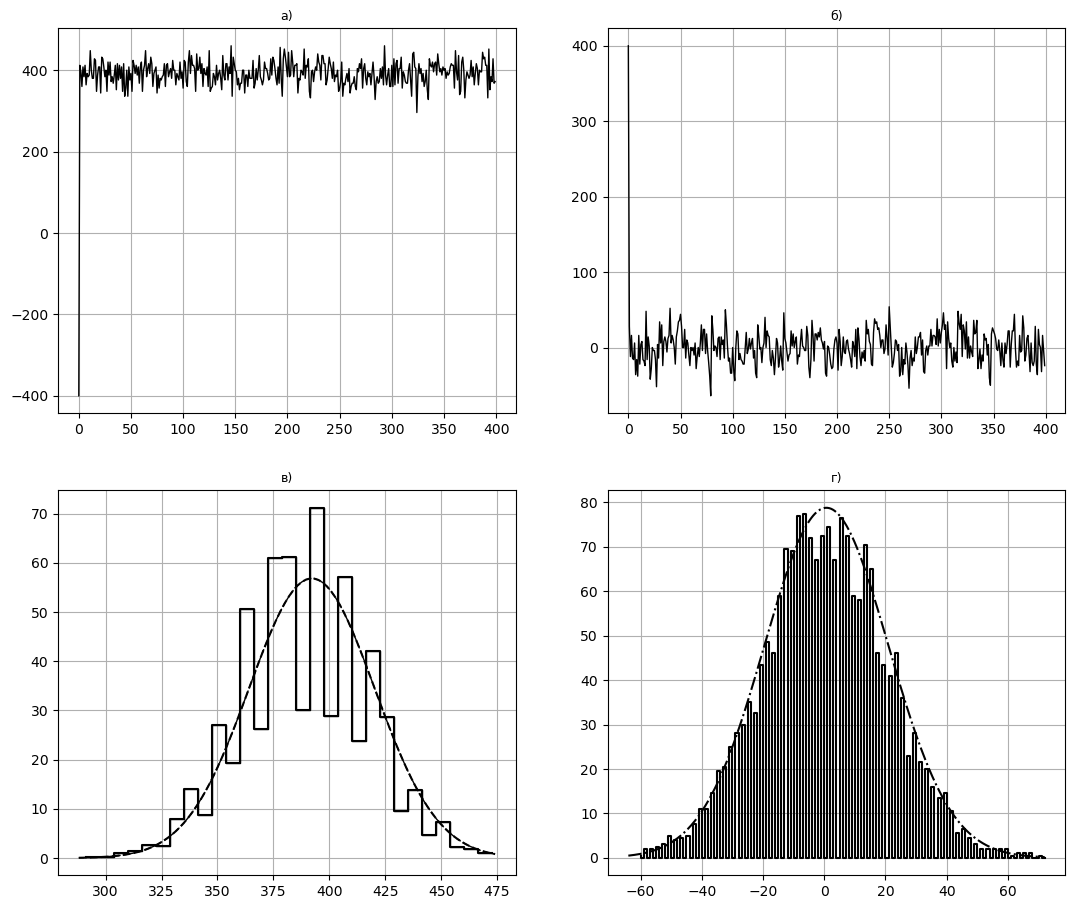

In [ ]:
# Ячейка № 3

# визуализация последовательностей,
# составленных из мгновенных значений
# энергии моделируемой системы,
# полного магнитного момента системы и
# их эмпирических плотностей распределений

fig = plt.figure(figsize=(13, 11))

# визуализация последовательности,
# составленной из мгновенных значений
# энергии системы
ax = plt.subplot(2, 2, 1)
plt.plot(E_System[0:400], "-k", lw=1)
plt.grid(True)
ax.set_title("а)", fontsize=9)

ax = plt.subplot(2, 2, 2)
plt.plot(Summary_Spin_Moment[0:400], "-k", lw=1)
plt.grid(True)
ax.set_title("б)", fontsize=9)

# визуализация распределения последовательности,
# составленной из мгновенных значений энергии
# одномерной системы спинов, и соответствующего
# нормального закона распределения

# вычисление значений эмпирической
# эмпирической плотности распределения
# последовательности, составленной из мгновенных
# значений энергии системы спинов
N_bin = 30
H = np.histogram(E_System[200 : len(E_System)], bins=N_bin)

# вычисление координат
# центров интервалов гистограммы
x = np.zeros(len(H[1]) - 1)
for i in range(len(H[1]) - 1):
    x[i] = (H[1][i] + H[1][i + 1]) / 2

# вычисление координат узлов сетки,
# используемых для вычисления значений
# плотности соответствующего
# нормального распределения
N_bin = 100
xbins = np.arange(
    np.min(E_System[200 : len(E_System)]),
    np.max(E_System[200 : len(E_System)]),
    (max(E_System[200 : len(E_System)]) - min(E_System[200 : len(E_System)])) / N_bin,
)

# вычисление значения плотности
# соответствующего нормального распределения
# N(x,np.mean(E_System),np.std(E_System)),
# в качестве параметров которого использованы
# их оценки, вычисленные на основе значений,
# находящихся в массиве E_System
dP_est = norm.pdf(
    xbins, np.mean(E_System[200 : len(E_System)]), np.std(E_System[200 : len(E_System)])
)

# визуализация эмпирической плотности распределения
# и сответствующего нормального распределения
ax = plt.subplot(2, 2, 3)
plt.step(x, H[0] / (x[1] - x[0]), "-k", lw=1)
plt.plot(xbins, len(E_System) * dP_est, "--k", lw=1)
plt.grid(True)
ax.set_title("в)", fontsize=9)

# визуализация эмпирической плотности
# распределения последовательности,
# составленной из мгновенных значений суммарного
# магнитного момента одномерной системы спинов,
# и аппроксимации данного нормального закона распределения

# вычисление значений эмпирической
# эмпирической плотности распределения
# последовательности, составленной из мгновенных
# значений энергии системы спинов
N_bin = 30
H = np.histogram(E_System[200 : len(E_System)], bins=N_bin)

# вычисление координат
# центров интервалов гистограммы
x = np.zeros(len(H[1]) - 1)
for i in range(len(H[1]) - 1):
    x[i] = (H[1][i] + H[1][i + 1]) / 2

# вычисление координат узлов сетки,
# используемых для вычисления значений
# плотности соответствующего
# нормального распределения
N_bin = 100
xbins = np.arange(
    np.min(E_System[200 : len(E_System)]),
    np.max(E_System[200 : len(E_System)]),
    (max(E_System[200 : len(E_System)]) - min(E_System[200 : len(E_System)])) / N_bin,
)

# вычисление значения плотности
# соответствующего нормального распределения
# N(x,np.mean(E_System),np.std(E_System)),
# в качестве параметров которого использованы
# их оценки, вычисленные на основе значений,
# находящихся в массиве E_System
dP_est = norm.pdf(
    xbins, np.mean(E_System[200 : len(E_System)]), np.std(E_System[200 : len(E_System)])
)

# визуализация эмпирической плотности распределения
# и сответствующего нормального распределения
ax = plt.subplot(2, 2, 3)
plt.step(x, H[0] / (x[1] - x[0]), color="black")
plt.plot(xbins, len(E_System) * dP_est, "--k")
plt.grid(True)
ax.set_title("в)", fontsize=9)

# визуализация эмпирической плотности
# распределения последовательности,
# составленной из мгновенных значений суммарного
# магнитного момента одномерной системы спинов,
# и аппроксимации данного нормального закона распределения

# вычисление эмпирической
# плотности распределения
# мгновенных значений энергии
# системы спинов

# задание числа интервалов гистограммы,
# обеспечивающего целое значение
# длины интервала гистограммы
N_bin = np.max(Summary_Spin_Moment[200 : len(E_System)].astype(int)) - np.min(
    Summary_Spin_Moment[200 : len(E_System)].astype(int)
)
H = np.histogram(Summary_Spin_Moment[200 : len(E_System)], bins=N_bin)

# формирование из упорядоченной последовательности
# последовательности элементов H,
# возвращаемой функцией histogram,
# массивов, содержащих значения
# левых границ интервалов гистограммы (массив H1), и
# число членов случайной последовательности,
# попавших в данный интервал гистограммы (массив H2)

H1 = np.zeros(int(len(H[1])))
H2 = np.zeros(int(len(H[1])))
k = 0
for i in range(len(H[1])):
    H2[k] = H[1][i]
    k = k + 1
k = 0
H1 = H1.astype(int)
for i in range(len(H[0]) - 1):
    H1[k] = H[0][i]
    k = k + 1
H1[k] = H[0][len(H[0]) - 1]

# вычисление координат узлов сетки,
# в которых вычисляются значения
# теоретической плотности распределения,
# используемой для аппроксимации эмпирической
# плотности распределения последовательности,
# составленной из мгновенных значений
# суммарного магнитного момента
# линейной системы спинов
N_bin = N_bin = np.max(Summary_Spin_Moment) - np.min(Summary_Spin_Moment)
xbins = np.arange(
    np.min(Summary_Spin_Moment[50 : len(E_System)]),
    np.max(Summary_Spin_Moment[50 : len(E_System)]),
    (
        max(Summary_Spin_Moment[50 : len(E_System)])
        - min(Summary_Spin_Moment[50 : len(E_System)])
    )
    / N_bin,
)

# вычисление значения плотности
# нормального распределения
# N(x,np.mean(Summary_Spin_Moment),np.std(Summary_Spin_Moment)),
# в качестве параметров которого использованы
# их оценки, вычисленные на основе значений,
# находящихся в массиве Summary_Spin_Moment
dP_est = norm.pdf(
    xbins,
    np.mean(Summary_Spin_Moment[50 : len(E_System)]),
    np.std(Summary_Spin_Moment[50 : len(E_System)]),
)

# визуализация эмпирической плотности распределения
# и его аппроксимации соответствующим
# нормальным распределением
ax = plt.subplot(2, 2, 4)

# при построении гистограммы массив H1
# нормируется на удвоенное значение длины
# интервала гистограммы, так как значения
# последовательных дискретных случайных величин,
# отличаются друг от друга на плюс/минус 2
plt.step(H2, H1 / (2 * (H2[1] - H2[0])), color="black")
plt.plot(xbins, len(Summary_Spin_Moment) * dP_est, "-.k")
plt.grid(True)
ax.set_title("г)", fontsize=9)

plt.show()

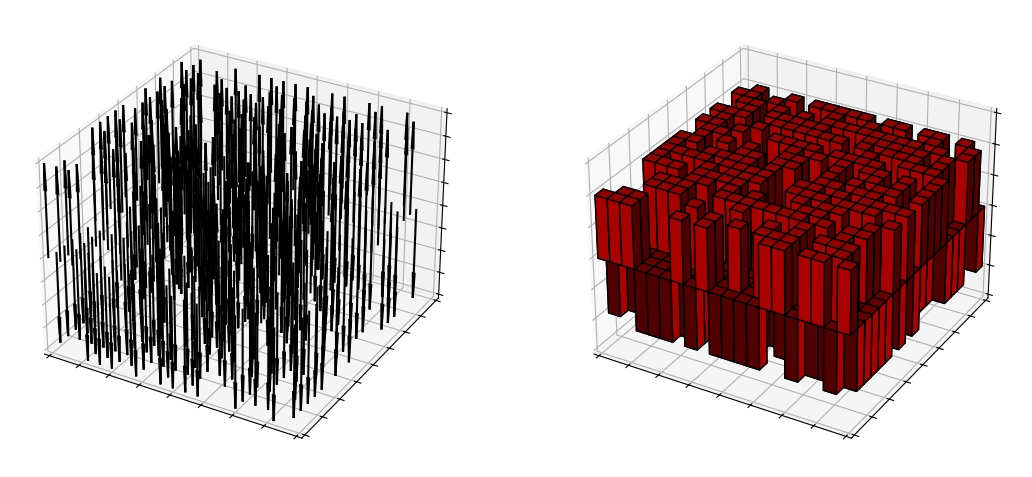

In [ ]:
# Ячейка № 4

# визуализация конфигурации спинов,
# соответствующей выбранному номеру
# шага метода Монте-Карло

# задание номера шага метода Монте-Карло
Number_Step_MK = 1000

# создание в узлах использованной
# координатной сетки единичных векторов,
# сонаправленных с соответствующими спинами
soa = np.zeros([N_x * N_y, 6])
k = 0
for i in range(N_x):
    for j in range(N_y):
        soa[k][0] = i
        soa[k][1] = j
        soa[k][5] = s[i, j, Number_Step_MK]
        k = k + 1
X, Y, Z, U, V, W = zip(*soa)

# визуализация мгновенной
# конфигурации спинов
# набора единичных векторов
fig = plt.figure(figsize=(13, 11))
ax = fig.add_subplot(121, projection="3d")
ax.quiver(X, Y, Z, U, V, W, color="black")
ax.set_xlim([0, N_x])
ax.set_ylim([0, N_y])
ax.set_zlim([-1, 1])

ax.set(xticklabels=[], yticklabels=[], zticklabels=[])
plt.style.use("_mpl-gallery")
ax = fig.add_subplot(122, projection="3d")

# визуализация мгновенной
# конфигурации спинов
# набора параллелепипедов, расположенных
# вдоль оси OZ в соответствии с ориентацией спинов

for i in range(N_x):
    for j in range(N_y):
        x = i
        y = j
        z = 0
        dx = 1
        dy = 1
        dz = s[i, j, Number_Step_MK]
        ax.bar3d(x, y, z, dx, dy, dz, alpha=1, color=(0.75, 0, 0, 0), edgecolor="black")
ax.set_xlim([0, N_x])
ax.set_ylim([0, N_y])
ax.set_zlim([-1.5, 1.5])
ax.set(xticklabels=[], yticklabels=[], zticklabels=[])

plt.show()